# Project 3: NLP Business Case: Automated Customers Reviews 🤖


## Primary Dataset: [Amazon Product Reviews](https://www.kaggle.com/datasets/datafiniti/consumer-reviews-of-amazon-products/data)

In [3]:
import pandas as pd

data = pd.read_csv("Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv")
data.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


**The important columns**
* reviews.rating -> Used to generate sentiment labels (Negative / Neutral / Positive)
* reviews.text -> This is the input text for the classification model
* name or primaryCategories	-> Needed later for clustering and summarization

# 1️⃣ Data Preparation

In [4]:
# Select only the important columns
data = data[['reviews.rating', 'reviews.text', 'name', 'primaryCategories']].copy()

# Drop any rows with missing values
data.dropna(inplace=True)

# The number of reviews after cleaning
print(f"Number of reviews after cleaning: {len(data)}")

data.head()

Number of reviews after cleaning: 28332


,reviews.rating,reviews.text,name,primaryCategories
0,3,I order 3 of them and one of the item is bad q...,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty
1,4,Bulk is always the less expensive way to go fo...,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty
2,5,Well they are not Duracell but for the price i...,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty
3,5,Seem to work as well as name brand batteries a...,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty
4,5,These batteries are very long lasting the pric...,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty


In [5]:
import re

def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'<.*?>', '', text)
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    return ""

data['cleaned_review'] = data['reviews.text'].apply(clean_text)

In [6]:
def get_sentiment(rating):
    if rating in [1, 2]:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    elif rating in [4, 5]:
        return 'Positive'
    else:
        return None

data['sentiment'] = data['reviews.rating'].apply(get_sentiment)

sentiment
Positive    25545
Negative     1581
Neutral      1206
Name: count, dtype: int64


<ipython-input-7-9145c18c52dd>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')


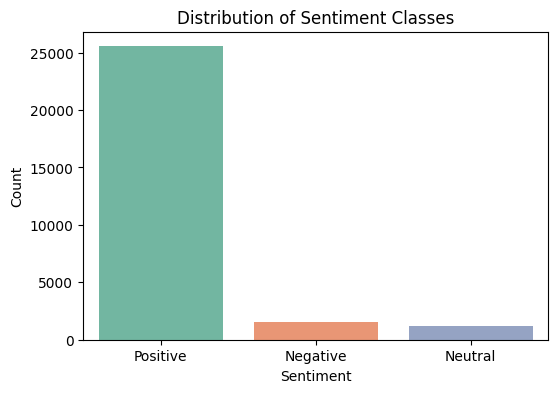

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = data['sentiment'].value_counts()

print(sentiment_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')
plt.title('Distribution of Sentiment Classes')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [8]:
# Encode labels numerically
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
data['label'] = data['sentiment'].map(label_map)
data

,reviews.rating,reviews.text,name,primaryCategories,cleaned_review,sentiment,label
0,3,I order 3 of them and one of the item is bad q...,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,i order 3 of them and one of the item is bad q...,Neutral,1
1,4,Bulk is always the less expensive way to go fo...,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,bulk is always the less expensive way to go fo...,Positive,2
2,5,Well they are not Duracell but for the price i...,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,well they are not duracell but for the price i...,Positive,2
3,5,Seem to work as well as name brand batteries a...,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,seem to work as well as name brand batteries a...,Positive,2
4,5,These batteries are very long lasting the pric...,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,these batteries are very long lasting the pric...,Positive,2
...,...,...,...,...,...,...,...
28327,5,I got 2 of these for my 8 yr old twins. My 11 ...,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",Electronics,i got 2 of these for my 8 yr old twins my 11 y...,Positive,2
28328,4,I bought this for my niece for a Christmas gif...,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",Electronics,i bought this for my niece for a christmas gif...,Positive,2
28329,5,"Very nice for light internet browsing, keeping...","Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",Electronics,very nice for light internet browsing keeping ...,Positive,2
28330,5,This Tablet does absolutely everything I want!...,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",Electronics,this tablet does absolutely everything i want ...,Positive,2


In [9]:
# Split the data into training and test data
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    data['cleaned_review'].tolist(),
    data['label'].tolist(),
    test_size=0.2,
    stratify= data['label'],
    random_state=42
)

# Create training and validation DataFrames
train_df = pd.DataFrame({'cleaned_review': train_texts, 'label': train_labels})
val_df = pd.DataFrame({'cleaned_review': val_texts, 'label': val_labels})

In [10]:
sentiment_counts = train_df['label'].value_counts()


print(sentiment_counts)

label
2    20435
0     1265
1      965
Name: count, dtype: int64


Ways used to slove imbalanced data :
* **class weights**: Adjusting the loss function to give more importance to the minority class during training.
* **data augmentation**:  Generating synthetic samples for the minority class to increase its representation.
* **Oversampling**: A technique used to handle imbalanced data by increasing the number of samples in the minority class




### Oversampling (Better improvement)

In [ ]:
from sklearn.utils import resample

negative_df = train_df[train_df['label'] == 0]
neutral_df  = train_df[train_df['label'] == 1]
positive_df = train_df[train_df['label'] == 2]

target_size = max(len(negative_df), len(neutral_df), len(positive_df))

negative_upsampled = resample(negative_df, replace=True, n_samples=target_size, random_state=42)
neutral_upsampled  = resample(neutral_df, replace=True, n_samples=target_size, random_state=42)
positive_upsampled = resample(positive_df, replace=True, n_samples=target_size, random_state=42)

train_df_balanced = pd.concat([negative_upsampled, neutral_upsampled, positive_upsampled]).sample(frac=1, random_state=42)


In [ ]:
print(train_df_balanced['label'].value_counts())

label
1    20435
0    20435
2    20435
Name: count, dtype: int64


### Data Augmentation & Undersampling (Slight improvement)

In [ ]:
!pip install nlpaug
import nltk
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
import nlpaug.augmenter.word as naw

# Initialize the augmenter with the pre-trained DistilBERT model
augmenter = naw.ContextualWordEmbsAug(model_path='distilbert-base-uncased', action="substitute")

# Create a copy of the neutral dataframe for augmentation
neutral_augmented = neutral_df.copy()

# Apply the augmenter to the 'cleaned_review' column
neutral_augmented['cleaned_review'] = neutral_augmented['cleaned_review'].apply(
    lambda x: augmenter.augment(x)[0] if isinstance(augmenter.augment(x), list) else augmenter.augment(x)
)

# Combine the augmented neutral reviews with the original training data
train_df_augmented = pd.concat([train_df, neutral_augmented]).sample(frac=1, random_state=42)



In [ ]:
print(train_df_augmented['label'].value_counts())

label
2    20435
1     1930
0     1265
Name: count, dtype: int64


In [ ]:
# Separate the augmented data by label (Negative, Neutral, Positive)
negative_df = train_df_augmented[train_df_augmented['label'] == 0]  # Negative class
neutral_df  = train_df_augmented[train_df_augmented['label'] == 1]  # Neutral class
positive_df = train_df_augmented[train_df_augmented['label'] == 2]  # Positive class

# Determine the smallest size among the classes
target_size = min(len(negative_df), len(neutral_df))  # Use the smallest class size

# Apply undersampling to the Positive class
positive_undersampled = positive_df.sample(n=target_size, random_state=42)

# Concatenate the classes back together after undersampling
train_df_undersampled = pd.concat([negative_df, neutral_df, positive_undersampled]).sample(frac=1, random_state=42)

print(train_df_undersampled['label'].value_counts())

### Tokenizer

In [ ]:
from transformers import DistilBertTokenizerFast
# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')


train_texts = train_df_balanced['cleaned_review'].tolist()
train_labels = train_df_balanced['label'].tolist()

val_texts = val_df['cleaned_review'].tolist()
val_labels = val_df['label'].tolist()

# Apply tokenizer
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

### Class Weights (Slight improvement)

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1, 2]), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float)


class_weights

tensor([6.2266, 4.0812, 0.3854])

In [ ]:
for label, idx in label_map.items():
    print(f"{label}: {idx}, count: {(train_df_augmented['label'] == idx).sum()}")
    print(f"{label} (label {idx}): weight = {class_weights[idx]:.4f}")
    print("================================================================")


Negative: 0, count: 1265
Negative (label 0): weight = 6.2266
Neutral: 1, count: 1930
Neutral (label 1): weight = 4.0812
Positive: 2, count: 20435
Positive (label 2): weight = 0.3854


#  2️⃣ Review Classification

### HuggingFace Datasets for Trainer

In [ ]:
!pip install transformers datasets scikit-learn

In [ ]:
# HuggingFace Dataset
from datasets import Dataset

train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': train_labels
})

val_dataset = Dataset.from_dict({
    'input_ids': val_encodings['input_ids'],
    'attention_mask': val_encodings['attention_mask'],
    'labels': val_labels
})

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
from transformers import DistilBertForSequenceClassification, DistilBertConfig, TrainingArguments, Trainer
from transformers import EvalPrediction
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch.nn import CrossEntropyLoss

# Load model
# Create a config with a higher dropout rate
config = DistilBertConfig.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    dropout=0.4,
    attention_dropout=0.4
)

# Load the model with the new config
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    config=config
)
# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss
1,0.306200,0.198283
2,0.215700,0.215995
3,0.180100,0.191428
4,0.153600,0.205137
5,0.123000,0.222000


TrainOutput(global_step=7385, training_loss=0.21794453506624692, metrics={'train_runtime': 1338.7706, 'train_samples_per_second': 88.253, 'train_steps_per_second': 5.516, 'total_flos': 1.56513022649856e+16, 'train_loss': 0.21794453506624692, 'epoch': 5.0})

              precision    recall  f1-score   support

    Negative       0.70      0.78      0.74       316
     Neutral       0.57      0.32      0.41       241
    Positive       0.97      0.99      0.98      5110

    accuracy                           0.95      5667
   macro avg       0.74      0.70      0.71      5667
weighted avg       0.94      0.95      0.94      5667



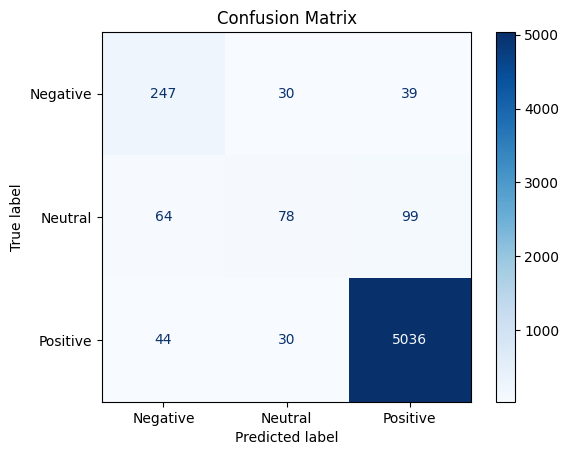

In [ ]:
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds_output = trainer.predict(val_dataset)
preds = np.argmax(preds_output.predictions, axis=1)

print(classification_report(preds_output.label_ids, preds, target_names=['Negative', 'Neutral', 'Positive']))

cm = confusion_matrix(preds_output.label_ids, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Neutral', 'Positive'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.save_pretrained("best_sentiment_model")
tokenizer.save_pretrained("best_sentiment_model")

('best_sentiment_model/tokenizer_config.json',
 'best_sentiment_model/special_tokens_map.json',
 'best_sentiment_model/vocab.txt',
 'best_sentiment_model/added_tokens.json',
 'best_sentiment_model/tokenizer.json')

# 3️⃣ Product Category Clustering


### Generate embeddings using a transformer model distilbert-base-uncased

In [1]:
from transformers import DistilBertModel, DistilBertTokenizerFast

# Load model
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [22]:
# Extract embeddings from the trained model (DistilBert)  instead of classification
from transformers import DistilBertModel
import torch
import numpy as np

def get_bert_embeddings(text, tokenizer, model, device='cpu'):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return embedding

data_cluster = data[["name"]].drop_duplicates()
# Step 1: Generate BERT embeddings from the text
embeddings = np.vstack([get_bert_embeddings(text, tokenizer, model) for text in data_cluster["name"]])

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 2: Apply KMeans clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)

# Step 3: Add cluster labels back to the original DataFrame
data_cluster['cluster'] = cluster_labels

# Step 4: Display basic clustering information
print(f"Cluster labels: {set(cluster_labels)}")
print(data_cluster[['name', 'cluster']].head())

Cluster labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}
                                                   name  cluster
0     AmazonBasics AAA Performance Alkaline Batterie...        0
8343    AmazonBasics Nylon CD/DVD Binder (400 Capacity)        0
8347                              Amazon Echo ‚Äì White        2
8349                           Amazon Echo Show - Black        2
8350                         Echo Spot Pair Kit (Black)        4


**The Silhouette Score**: it is a metric used to evaluate the quality of clusters formed by a clustering algorithm, such as K-Means. It measures how similar each point is to its own cluster (cohesion) compared to other clusters (separation).

The score ranges from -1 to 1,
* 1 indicates well-defined clusters with clear separation,
* A value near 0 suggests overlapping clusters
* Negative value indicates that the points might have been incorrectly clustered.

A higher silhouette score indicates better clustering.

In [13]:
# Step 5: Evaluate clustering using Silhouette Score
score = silhouette_score(embeddings, cluster_labels)
print(f"Silhouette Score for KMeans clustering: {score:.4f}")

Silhouette Score for KMeans clustering: 0.1696


### Analyze and label the resulting clusters

In [14]:
# Display number of items in each cluster
cluster_counts = data_cluster['cluster'].value_counts().sort_index()
print("\nNumber of items in each cluster:")
print(cluster_counts)


Number of items in each cluster:
cluster
0     8
1    13
2    10
3    16
4    18
Name: count, dtype: int64


In [31]:
# View sample texts per cluster
for cluster_id in range(n_clusters):
    print(f"\nSample texts from Cluster {cluster_id}:")
    sample_texts = data_cluster[data_cluster['cluster'] == cluster_id]['name'].unique()
    for text in sample_texts:
        print("-", text)


Sample texts from Cluster 0:
- AmazonBasics AAA Performance Alkaline Batteries (36 Count)
- AmazonBasics Nylon CD/DVD Binder (400 Capacity)
- Fire TV Stick Streaming Media Player Pair Kit
- AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary
- AmazonBasics Ventilated Adjustable Laptop Stand
- Expanding Accordion File Folder Plastic Portable Document Organizer Letter Size
- Cat Litter Box Covered Tray Kitten Extra Large Enclosed Hooded Hidden Toilet
- AmazonBasics Silicone Hot Handle Cover/Holder - Red
- Amazon Echo (1st Generationcertified) Color:White Free Shipping
- Amazon Tap Smart Assistant Alexaenabled (black) Brand New
- AmazonBasics USB 3.0 Cable - A-Male to B-Male - 6 Feet (1.8 Meters)
- Two Door Top Load Pet Kennel Travel Crate Dog Cat Pet Cage Carrier Box Tray 23"
- AmazonBasics 16-Gauge Speaker Wire - 100 Feet
- Amazon Echo (2nd Generation) Smart Assistant Oak Finish Priority Shipping
- AmazonBasics Nespresso Pod Storage Drawer - 50 Capsule Capaci

### label the clusters

In [32]:
# Cluster names based on the analysis of top words
cluster_names = {
    0: "Pet & Home Essentialss",
    1: "E-Readers & Kids Tablets",
    2: "Smart Home Devices & Accessories",
    3: "Fire Tablets",
    4: "Accessories"
}

# Map cluster names to the data
data_cluster['cluster_name'] = data_cluster['cluster'].map(cluster_names)

# Show the resulting cluster names and reviews
cluster_counts = data_cluster['cluster_name'].value_counts().sort_index()

# Print the number of items in each cluster
print("\nNumber of items in each cluster:")
print(cluster_counts)

print("============================================================================")

print("\nSample Data:")
data_cluster


Number of items in each cluster:
cluster_name
Accessories                          3
E-Readers & Kids Tablets            20
Fire Tablets                        21
Pet & Home Essentialss              18
Smart Home Devices & Accessories     3
Name: count, dtype: int64

Sample Data:


,name,cluster,cluster_name
0,AmazonBasics AAA Performance Alkaline Batterie...,0,Pet & Home Essentialss
8343,AmazonBasics Nylon CD/DVD Binder (400 Capacity),0,Pet & Home Essentialss
8347,Amazon Echo ‚Äì White,2,Smart Home Devices & Accessories
8349,Amazon Echo Show - Black,2,Smart Home Devices & Accessories
8350,Echo Spot Pair Kit (Black),4,Accessories
...,...,...,...
25864,Certified Refurbished Amazon Fire TV with Alex...,0,Pet & Home Essentialss
25871,All-New Kindle Oasis E-reader - 7 High-Resolut...,3,Fire Tablets
25878,AmazonBasics Bluetooth Keyboard for Android De...,3,Fire Tablets
25884,Amazon Kindle Replacement Power Adapter (Fits ...,3,Fire Tablets


### Cosine Similarity

One common method to evaluate how well a cluster name matches the data it contains is by calculating the cluster's fit score using a similarity measure like Cosine Similarity.

Cosine Similarity is a metric used to calculate the similarity between texts or objects based on the angles between their vector representations in a multidimensional space. The similarity score between texts ranges from 0 to 1, where a value closer to 1 indicates a high degree of similarity between the texts.

In [33]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def cluster_name_fit_score(samples, name, tokenizer, model, device='cpu'):
    name_embedding = get_bert_embeddings(name, tokenizer, model, device)

    sample_embeddings = np.array([get_bert_embeddings(sample, tokenizer, model, device) for sample in samples])

    similarities = cosine_similarity(sample_embeddings, name_embedding.reshape(1, -1))
    avg_similarity = np.mean(similarities)

    return avg_similarity

In [34]:
cluster0_samples = [
"AmazonBasics AAA Performance Alkaline Batteries (36 Count)",
"Cat Litter Box Covered Tray Kitten Extra Large Enclosed Hooded Hidden Toilet",
"AmazonBasics USB 3.0 Cable - A-Male to B-Male - 6 Feet (1.8 Meters)",
"Two Door Top Load Pet Kennel Travel Crate Dog Cat Pet Cage Carrier Box Tray 23",
"AmazonBasics 16-Gauge Speaker Wire - 100 Feet",
"All-new Echo (2nd Generation) with improved sound, powered by Dolby, and a new design Walnut Finish",
"AmazonBasics Single-Door Folding Metal Dog Crate - Large (42x28x30 Inches)",
"AmazonBasics Double-Door Folding Metal Dog Crate - Medium (36x23x25 Inches)"
]

cluster1_samples = [
"All-New Kindle E-reader - Black, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers",
"Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers",
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Pink Kid-Proof Case",
"Kindle Oasis E-reader with Leather Charging Cover - Black, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers",
"Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Free 3G + Wi-Fi - Includes Special Offers",
"Kindle Oasis E-reader with Leather Charging Cover - Merlot, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers",
"All-New Kindle Oasis E-reader - 7 High-Resolution Display (300 ppi), Waterproof, Built-In Audible, 32 GB, Wi-Fi + Free Cellular Connectivity",
"Kindle Oasis E-reader with Leather Charging Cover - Walnut, 6 High-Resolution Display (300 ppi), Wi-Fi - Includes Special Offers",
"All-New Kindle Oasis E-reader - 7 High-Resolution Display (300 ppi), Waterproof, Built-In Audible, 8 GB, Wi-Fi - Includes Special Offers",
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Blue Kid-Proof Case",
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case",
"Kindle E-reader - White, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers",
"All-New Kindle Oasis E-reader - 7 High-Resolution Display (300 ppi), Waterproof, Built-In Audible, 32 GB, Wi-Fi - Includes Special Offers "
                   ]

cluster2_samples = [
"Amazon Echo ‚Äì White",
"Amazon Echo Show - Black",
"Echo Spot Pair Kit (Black)",
"Fire TV Stick Streaming Media Player Pair Kit",
"AmazonBasics External Hard Drive Case",
"Expanding Accordion File Folder Plastic Portable Document Organizer Letter Size",
"Certified Refurbished Amazon Echo",
"Echo Dot (Previous generation)",
"Amazon Fire TV Gaming Edition Streaming Media Player",
"Certified Refurbished Amazon Fire TV with Alexa Voice Remote"
]

cluster3_samples = [
" - All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Black",
"- All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Magenta",
"- All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Black",
"- All-New Fire 7 Tablet with Alexa, 7 Display, 8 GB - Marine Blue",
"- Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black",
"- All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Blue",
"- All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Blue",
"- Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Silver Aluminum",
"- All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Pink Kid-Proof Case",
"- All-New Fire HD 8 Kids Edition Tablet, 8 HD Display, 32 GB, Blue Kid-Proof Case",
"- All-New Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Marine Blue - with Special Offers",
"- All-New Fire HD 8 Tablet with Alexa, 8 HD Display, 32 GB, Marine Blue - with Special Offers",
"- Fire Tablet with Alexa, 7 Display, 16 GB, Magenta - with Special Offers",
"- Fire Tablet with Alexa, 7 Display, 16 GB, Blue - with Special Offers",
"- Fire HD 8 Tablet with Alexa, 8 HD Display, 32 GB, Tangerine - with Special Offers",
"- Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Tangerine - with Special Offers"
]

cluster4_samples = [
"AmazonBasics Nylon CD/DVD Binder (400 Capacity)",
"AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary",
"AmazonBasics Ventilated Adjustable Laptop Stand",
"AmazonBasics Backpack for Laptops up to 17-inches",
"AmazonBasics 11.6-Inch Laptop Sleeve",
"AmazonBasics 15.6-Inch Laptop and Tablet Bag",
"Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle eReaders",
"Kindle PowerFast International Charging Kit (for accelerated charging in over 200 countries)",
"AmazonBasics Silicone Hot Handle Cover/Holder - Red",
"Amazon Kindle Charger Power Adapter Wall Charger And Usb Cable Micro Usb Cord",
"Amazon Echo (1st Generationcertified) Color:White Free Shipping",
"Amazon Tap Smart Assistant Alexaenabled (black) Brand New",
"Oem Amazon Kindle Power Usb Adapter Wall Travel Charger Fire/dx/+micro Usb Cable",
"Amazon Echo (2nd Generation) Smart Assistant Oak Finish Priority Shipping",
"AmazonBasics Nespresso Pod Storage Drawer - 50 Capsule Capacity",
"Amazon Fire HD 8 with Alexa (8 HD Display Tablet)",
"AmazonBasics Bluetooth Keyboard for Android Devices - Black",
"Amazon Kindle Replacement Power Adapter (Fits Latest Generation Kindle and Kindle DX) For shipment in the U.S only"

]


In [35]:
cluster_names = {
    0: "Pet & Home Essentialss",
    1: "E-Readers & Kids Tablets",
    2: "Smart Home Devices & Accessories",
    3: "Fire Tablets",
    4: "Accessories"
}

all_clusters = [
    cluster0_samples,
    cluster1_samples,
    cluster2_samples,
    cluster3_samples,
    cluster4_samples
    ]

for i, samples in enumerate(all_clusters):
    name = cluster_names[i]
    score = cluster_name_fit_score(samples, name, tokenizer, model)
    print(f"Cluster {i} - '{name}' → Fit score: {score:.3f}")


Cluster 0 - 'Pet & Home Essentialss' → Fit score: 0.673
Cluster 1 - 'E-Readers & Kids Tablets' → Fit score: 0.711
Cluster 2 - 'Smart Home Devices & Accessories' → Fit score: 0.677
Cluster 3 - 'Fire Tablets' → Fit score: 0.513
Cluster 4 - 'Accessories' → Fit score: 0.437


In [26]:
import pandas as pd
from google.colab import files

# Save the DataFrame to a CSV file
data_cluster.to_csv('data_cluster.csv', index=False)
files.download('data_cluster.csv')
data_cluster

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,name,cluster
0,AmazonBasics AAA Performance Alkaline Batterie...,0
8343,AmazonBasics Nylon CD/DVD Binder (400 Capacity),0
8347,Amazon Echo ‚Äì White,2
8349,Amazon Echo Show - Black,2
8350,Echo Spot Pair Kit (Black),4
...,...,...
25864,Certified Refurbished Amazon Fire TV with Alex...,0
25871,All-New Kindle Oasis E-reader - 7 High-Resolut...,3
25878,AmazonBasics Bluetooth Keyboard for Android De...,3
25884,Amazon Kindle Replacement Power Adapter (Fits ...,3


# 4️⃣ Review Summarization Using Generative AI


In [19]:
pip install openai==0.28

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 2.2 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.70.0
    Uninstalling openai-1.70.0:
      Successfully uninstalled openai-1.70.0


In [37]:
import openai
from google.colab import userdata

# Get API key
openai.api_key = userdata.get('openai.api_key')

# Create a chat completion
response = openai.ChatCompletion.create(
    model="gpt-4",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Hello!"}
    ]
)

# Print the result
print(response['choices'][0]['message']['content'])


Hello! How can I assist you today?



In [39]:
data_summarize = data[["sentiment", "cleaned_review", "reviews.rating"]].drop_duplicates()

combined_df = pd.concat([data_cluster, data_summarize], axis=1)
combined_df.dropna(inplace=True)
combined_df.head()

,name,cluster,cluster_name,sentiment,cleaned_review,reviews.rating
0,AmazonBasics AAA Performance Alkaline Batterie...,0.0,Pet & Home Essentialss,Neutral,i order 3 of them and one of the item is bad q...,3.0
8343,AmazonBasics Nylon CD/DVD Binder (400 Capacity),0.0,Pet & Home Essentialss,Positive,great case to keep everything in its place my ...,5.0
8347,Amazon Echo ‚Äì White,2.0,Smart Home Devices & Accessories,Positive,pros standard echo cons older generation echo ...,5.0
8349,Amazon Echo Show - Black,2.0,Smart Home Devices & Accessories,Positive,pros i love the alexa series so when this one ...,5.0
8350,Echo Spot Pair Kit (Black),4.0,Accessories,Positive,aside from the fact that the screen is small i...,4.0


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
import openai

category_blog_posts = {}

# Loop through each product category (cluster)
for category in combined_df['cluster_name'].unique():
    df_cat = combined_df[combined_df['cluster_name'] == category]

    # Step 1: Identify top 3 highest-rated products in the category
    top_df = df_cat[df_cat['sentiment'] == 'Positive']
    top_products = top_df.groupby('name')['reviews.rating'].mean().sort_values(ascending=False).head(3).reset_index()

    # Step 2: Extract most frequent complaints from negative reviews
    neg_reviews = df_cat[df_cat['sentiment'] == 'Negative']
    neg_reviews = neg_reviews[neg_reviews['cleaned_review'].str.strip().astype(bool)]  # Remove empty reviews

    if not neg_reviews.empty:
        vectorizer = TfidfVectorizer(stop_words='english', max_features=10)
        X = vectorizer.fit_transform(neg_reviews['cleaned_review'])
        word_freq = dict(zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0)))
        sorted_complaints = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:5]
        complaint_list = [f"{word}: {freq}" for word, freq in sorted_complaints]
    else:
        complaint_list = []

    # Step 3: Identify the most negatively-reviewed product
    worst_product = neg_reviews.groupby('name')['reviews.rating'].count().sort_values(ascending=False).head(1).reset_index()

    # Step 4: Create a prompt to generate a summary using GPT
    prompt = f"""
    Here is a list of the top 3 products in the {category} category, including their ratings and features:

    {top_products[['name', 'reviews.rating']].to_string(index=False)}

    **Top Complaints for the products:**
    - {', '.join([c.split(':')[0] for c in complaint_list])}

    **Worst Product:**
    - {worst_product[['name', 'reviews.rating']].to_string(index=False)}

    Please generate a blog post that:
    1. Summarizes the top 3 products in the {category} category, highlighting their key features and why they stand out based on user reviews.
    2. Mentions the common complaints users have for these top products, and provides context for these complaints based on the reviews.
    3. Highlights the worst product in this category, explaining why it underperformed compared to the others, based on user feedback.
    4. Make the blog post engaging, clear, and informative, ensuring that readers can easily understand the key points about both the best and worst products in this category.
    """

    # Step 5: Send the prompt to GPT to generate the blog post
    response = openai.ChatCompletion.create(
      model="gpt-3.5-turbo",
      messages=[{"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": prompt}],
      max_tokens=500,
      temperature=0.7
    )

    blog_text = response['choices'][0]['message']['content']
    category_blog_posts[category] = blog_text

    print(f"----------------------💠 Blog generated for category: {category}💠----------------------")
    print(f"Blog Text: {blog_text}")


----------------------💠 Blog generated for category: Pet & Home Essentialss💠----------------------
Blog Text: **Blog Post: Unveiling the Best and Worst in Pet & Home Essentials**

In the vast world of Pet & Home Essentials, finding products that truly deliver on their promises can be a daunting task. To simplify your search, we've curated a list of the top 3 products in this category based on user reviews, along with insights into common complaints and the worst-performing product.

**Top 3 Products:**

1. **Amazon Echo (1st Generationcertified) Color:White Free Shipping**  
   - *Rating: 5.0*  
   - This smart assistant, equipped with Alexa, stands out for its seamless integration into your home. Users rave about its convenience and ease of use, making it a must-have for pet and home management.

2. **Amazon Tap Smart Assistant Alexaenabled (black) Brand New**  
   - *Rating: 5.0*  
   - With its portability and Alexa functionality, the Amazon Tap is a favorite among users. Its brand 

In [41]:
# Save each blog post as a text file

with open('Final_Output_all_blog_posts.txt', 'w', encoding='utf-8') as f:
    for category, blog in category_blog_posts.items():
        f.write(f"----------------------💠 Blog generated for category: {category} 💠----------------------\n")
        f.write(f"Blog Text: {blog}\n")
        f.write("\n\n")

print("All blog posts saved to one text file.")


All blog posts saved to one text file.
